Data loaded successfully!

First 5 rows:
   record_id  rotational_speed_rpm  load_kN  bearing_temperature_c  \
0          1                   850      3.5                     38   
1          2                   950      4.2                     40   
2          3                  1050      5.0                     42   
3          4                  1150      5.8                     44   
4          5                  1250      6.5                     46   

   lubricant_level_pct  vibration_mm_s  condition_class  
0                   96             1.1                0  
1                   93             1.3                0  
2                   90             1.5                0  
3                   88             1.7                0  
4                   85             2.0                0  

Data shape:
(30, 7)

Column information:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  

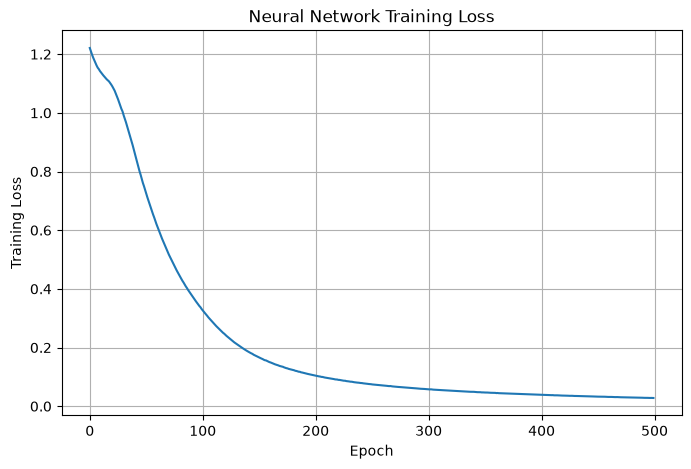


MODEL RESULTS

Test Accuracy: 1.000

Confusion Matrix:
[[2 0 0]
 [0 2 0]
 [0 0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


Individual test predictions:
   Actual  Predicted  Probability_Class_0  Probability_Class_1  \
0       2          2         3.242779e-07         1.187832e-09   
1       1          1         6.249725e-05         9.994990e-01   
2       2          2         5.876325e-05         8.459871e-04   
3       0          0         9.689415e-01         3.103919e-02   
4       1          1         1.224664e-04         9.994140e-01   
5       0          0         9.986546e-01         1.345021e-03   

   Probability_Cla

In [3]:
# ============================================================
# MECHANICAL DATA - PYTORCH DEEP LEARNING CLASSIFIER
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from torch.utils.data import TensorDataset, DataLoader


# ------------------------------------------------------------
# 2. LOAD THE DATA
# ------------------------------------------------------------

# Make sure mechanical.csv is in the same folder as
# this Jupyter notebook.

df = pd.read_csv("mechanical.csv")

print("Data loaded successfully!")
print()

print("First 5 rows:")
print(df.head())

print()
print("Data shape:")
print(df.shape)

print()
print("Column information:")
print(df.info())


# ------------------------------------------------------------
# 3. CHECK FOR MISSING VALUES
# ------------------------------------------------------------

print()
print("Missing values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 4. LOOK AT THE TARGET VARIABLE
# ------------------------------------------------------------

print()
print("Condition class counts:")
print(df["condition_class"].value_counts())

print()
print("Condition class percentages:")
print(df["condition_class"].value_counts(normalize=True))


# ------------------------------------------------------------
# 5. DEFINE FEATURES (X) AND TARGET (y)
# ------------------------------------------------------------

# record_id is only an identifier, so we do NOT use it
# as a machine-learning feature.

X = df.drop(
    columns=["record_id", "condition_class"]
)

y = df["condition_class"]


print()
print("Features:")
print(X.head())

print()
print("Target:")
print(y.head())


# ------------------------------------------------------------
# 6. SPLIT INTO TRAINING AND TESTING DATA
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print()
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ------------------------------------------------------------
# 7. STANDARDIZE THE FEATURES
# ------------------------------------------------------------

# Neural networks generally train better when numerical
# features are on similar scales.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# IMPORTANT:
# Only FIT the scaler on training data.
# The test data is only TRANSFORMED.

X_test_scaled = scaler.transform(X_test)


print()
print("Scaled training data:")
print(X_train_scaled[:5])


# ------------------------------------------------------------
# 8. CONVERT DATA TO PYTORCH TENSORS
# ------------------------------------------------------------

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)


print()
print("Tensor shapes:")
print("X_train:", X_train_tensor.shape)
print("X_test: ", X_test_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("y_test: ", y_test_tensor.shape)


# ------------------------------------------------------------
# 9. CREATE PYTORCH DATASETS
# ------------------------------------------------------------

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


# ------------------------------------------------------------
# 10. CREATE DATALOADERS
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)


# Check one training batch

print()
print("Checking DataLoader:")

for X_batch, y_batch in train_loader:

    print("X batch shape:", X_batch.shape)
    print("y batch shape:", y_batch.shape)

    break

# ============================================================
# 11. DEFINE THE NEURAL NETWORK
# ============================================================

import torch
import torch.nn as nn

class MechanicalNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # 5 input features
            nn.Linear(5, 16),

            nn.ReLU(),

            # Hidden layer
            nn.Linear(16, 8),

            nn.ReLU(),

            # 3 outputs because we have 3 classes:
            # 0, 1, and 2
            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.network(x)


# Create the model
model = MechanicalNet()

print("Neural network:")
print(model)


# ============================================================
# 12. LOSS FUNCTION
# ============================================================

# CrossEntropyLoss is used for multi-class classification.

criterion = nn.CrossEntropyLoss()


# ============================================================
# 13. OPTIMIZER
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# ============================================================
# 14. PREPARE TARGET TENSORS
# ============================================================

# CrossEntropyLoss requires class labels to be integers
# of type LongTensor.

y_train_tensor = y_train_tensor.long().reshape(-1)
y_test_tensor = y_test_tensor.long().reshape(-1)


# Re-create datasets because the target tensor changed

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


# Re-create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)


# ============================================================
# 15. TRAIN THE MODEL
# ============================================================

epochs = 500

training_losses = []

print()
print("Starting training...")
print()

for epoch in range(epochs):

    model.train()

    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        outputs = model(X_batch)

        # Calculate loss
        loss = criterion(
            outputs,
            y_batch
        )

        # Clear gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_loss += loss.item()


    # Average loss
    average_loss = epoch_loss / len(train_loader)

    training_losses.append(
        average_loss
    )


    # Display progress
    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {average_loss:.4f}"
        )


# ============================================================
# 16. PLOT TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(training_losses)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Neural Network Training Loss")

plt.grid(True)

plt.show()


# ============================================================
# 17. EVALUATE THE MODEL
# ============================================================

model.eval()

all_predictions = []
all_actual = []
all_probabilities = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        # Get model outputs
        outputs = model(X_batch)

        # Convert outputs into probabilities
        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        # Select class with highest probability
        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        # Store results
        all_predictions.extend(
            predictions.numpy()
        )

        all_actual.extend(
            y_batch.numpy()
        )

        all_probabilities.extend(
            probabilities.numpy()
        )


# Convert to NumPy arrays

all_predictions = np.array(
    all_predictions
)

all_actual = np.array(
    all_actual
)

all_probabilities = np.array(
    all_probabilities
)


# ============================================================
# 18. ACCURACY
# ============================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    all_actual,
    all_predictions
)

print()
print("==============================")
print("MODEL RESULTS")
print("==============================")

print()

print(
    f"Test Accuracy: {accuracy:.3f}"
)


# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_actual,
    all_predictions
)

print()
print("Confusion Matrix:")
print(cm)


# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print()
print("Classification Report:")

print(
    classification_report(
        all_actual,
        all_predictions,
        labels=[0, 1, 2],
        zero_division=0
    )
)


# ============================================================
# 21. SHOW INDIVIDUAL PREDICTIONS
# ============================================================

results = pd.DataFrame({

    "Actual": all_actual,

    "Predicted": all_predictions,

    "Probability_Class_0":
        all_probabilities[:, 0],

    "Probability_Class_1":
        all_probabilities[:, 1],

    "Probability_Class_2":
        all_probabilities[:, 2]

})


print()
print("Individual test predictions:")
print(results)


# ============================================================
# 22. CHECK CLASS DISTRIBUTION
# ============================================================

print()
print("Actual test classes:")
print(
    pd.Series(
        all_actual
    ).value_counts().sort_index()
)

print()

print("Predicted test classes:")
print(
    pd.Series(
        all_predictions
    ).value_counts().sort_index()
)

In [4]:

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score

# Epoch counts to compare
epoch_counts = [100, 200, 300, 400, 1000]

# Use the same training data for each experiment
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

# Store results for comparison
results = []
loss_curves = {}

# Use a fixed seed for reproducibility
base_seed = 42

for num_epochs in epoch_counts:
    print(f"\nTraining model for {num_epochs} epochs...")

    # Reset the seed so each experiment starts consistently
    torch.manual_seed(base_seed)

    # Create a fresh model for this experiment
    model = MechanicalNet()

    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epoch_losses = []

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        average_loss = running_loss / len(train_loader)
        epoch_losses.append(average_loss)

    loss_curves[num_epochs] = epoch_losses

    # Evaluate model on test data
    model.eval()

    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        predictions = torch.argmax(test_outputs, dim=1)

        accuracy = accuracy_score(
            y_test_tensor.numpy(),
            predictions.numpy()
        )

    results.append({
        "Epochs": num_epochs,
        "Final Training Loss": epoch_losses[-1],
        "Test Accuracy": accuracy
    })

    print(f"Final training loss: {epoch_losses[-1]:.4f}")
    print(f"Test accuracy: {accuracy:.2%}")

# Display comparison table
results_df = pd.DataFrame(results)
display(results_df)


Training model for 100 epochs...
Final training loss: 0.6567
Test accuracy: 100.00%

Training model for 200 epochs...
Final training loss: 0.3646
Test accuracy: 100.00%

Training model for 300 epochs...
Final training loss: 0.2379
Test accuracy: 100.00%

Training model for 400 epochs...
Final training loss: 0.1698
Test accuracy: 100.00%

Training model for 1000 epochs...
Final training loss: 0.0385
Test accuracy: 100.00%


,Epochs,Final Training Loss,Test Accuracy
0,100,0.656698,1.0
1,200,0.364628,1.0
2,300,0.237912,1.0
3,400,0.169772,1.0
4,1000,0.038463,1.0


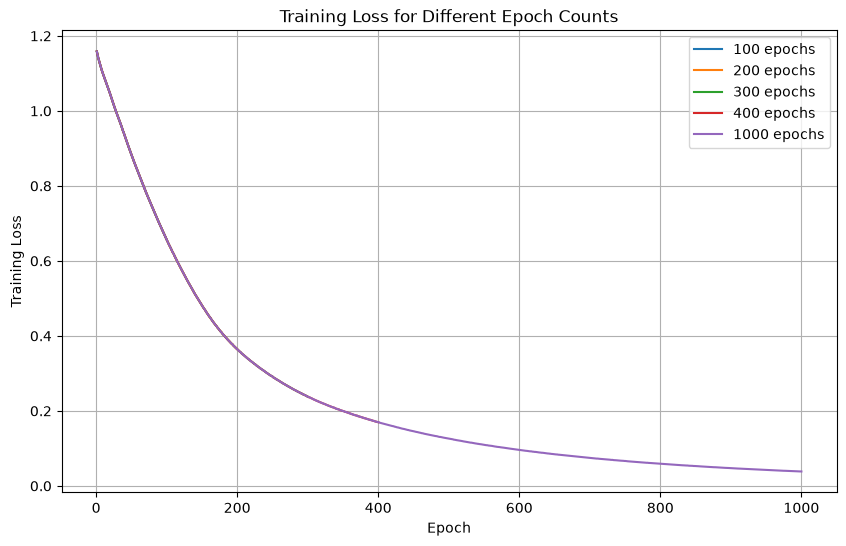

In [5]:

plt.figure(figsize=(10, 6))

for num_epochs, losses in loss_curves.items():
    plt.plot(
        range(1, num_epochs + 1),
        losses,
        label=f"{num_epochs} epochs"
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Epoch Counts")
plt.legend()
plt.grid(True)
plt.show()